In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 17: Use Oracle Distances to Diagnose Ranking Failure

**Objective:** Diagnose why the learned ranker fails by checking where the truly GT-near candidates appear in the model-ranked list.

# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- compute the true nearest-GT distance for each candidate
- identify which candidates are oracle-good candidates
- compare oracle-good candidates against model ranking positions
- measure how far down the ranked list good candidates appear
- decide whether ranking failure is mild or severe

# 🧠 Background Theory

In Chapter 16, 3D NMS helped reduce the candidate pool while preserving raw LoG recall. However, the learned top-k ranker still failed.

That means the next question is:

> Are GT-near candidates present but ranked too low?

If GT-near candidates are ranked around positions 60–150, the ranker may be close and could improve with a better cutoff or calibration.

If GT-near candidates are ranked around positions 400–800, then the model is severely misranking candidates.

This chapter uses oracle distances to diagnose the ranking failure directly.

# 🗺️ Chapter Roadmap

This notebook will proceed in seven stages:

1. **Load the sample and helper functions**
2. **Rebuild the LoG + NMS candidate pipeline**
3. **Train the same consolidated-candidate distance ranker**
4. **Apply the ranker to held-out timepoints**
5. **Compute the true oracle distance and rank position of each candidate**
6. **Summarize where GT-near candidates appear in the ranked list**
7. **Visualize model score vs oracle distance**

# 📚 New Vocabulary

## Oracle-Good Candidate
A candidate whose true nearest-GT distance is within the match radius.

## Rank Position
The candidate’s position after sorting by the model’s predicted score.

## Ranking Failure
A failure where good candidates exist, but the model assigns them low scores.

## Score Calibration
How well the model’s predicted scores correspond to true candidate quality.

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 49.6 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from skimage.feature import blob_log
from sklearn.ensemble import RandomForestRegressor

In [4]:
print("Imports successful.")

Imports successful.


# Step 1 — Load the Sample and Ground Truth

I will continue using sample `44b6_12dfb391` and the same train/test timepoint split from Chapters 12–16.

In [5]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

volume = zarr.open(zarr_path, mode="r")
image = volume["0"]

geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

print("Image shape:", image.shape)
print("GT nodes:", len(nodes_df))
nodes_df.head()

Image shape: (100, 64, 256, 256)
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


# Step 2 — Define Detection, NMS, Feature, and Distance Helpers

I will reuse the same LoG + NMS pipeline from Chapter 16.

In [6]:
def detect_blobs_log_3d_slicewise(
    frame_3d,
    min_sigma=2.5,
    max_sigma=3.5,
    num_sigma=3,
    threshold=0.15
):
    detections = []

    for z in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z].astype(np.float32)

        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max > s_min:
            slice_norm = (slice_2d - s_min) / (s_max - s_min)
        else:
            slice_norm = slice_2d

        blobs = blob_log(
            slice_norm,
            min_sigma=min_sigma,
            max_sigma=max_sigma,
            num_sigma=num_sigma,
            threshold=threshold
        )

        for blob in blobs:
            y, x, sigma = blob
            detections.append({
                "z": int(z),
                "y": int(round(y)),
                "x": int(round(x)),
                "sigma": float(sigma)
            })

    return pd.DataFrame(detections)

In [7]:
def add_center_intensity(frame_3d, pred_df):
    pred_df = pred_df.copy()
    intensities = []

    Z, Y, X = frame_3d.shape

    for _, row in pred_df.iterrows():
        z, y, x = int(row["z"]), int(row["y"]), int(row["x"])
        z = np.clip(z, 0, Z - 1)
        y = np.clip(y, 0, Y - 1)
        x = np.clip(x, 0, X - 1)

        intensities.append(float(frame_3d[z, y, x]))

    pred_df["center_intensity"] = intensities
    return pred_df

In [8]:
def consolidate_candidates_3d(pred_df, radius=3.0, score_col="center_intensity"):
    """
    Greedy 3D non-maximum suppression.
    """
    if len(pred_df) == 0:
        return pred_df.copy()

    work_df = pred_df.copy().sort_values(score_col, ascending=False).reset_index(drop=True)
    kept_rows = []

    while len(work_df) > 0:
        keep = work_df.iloc[0]
        kept_rows.append(keep)

        keep_point = np.array([keep["z"], keep["y"], keep["x"]], dtype=float)
        other_points = work_df[["z", "y", "x"]].to_numpy(dtype=float)

        dists = np.sqrt(((other_points - keep_point) ** 2).sum(axis=1))
        work_df = work_df[dists > radius].reset_index(drop=True)

    return pd.DataFrame(kept_rows).reset_index(drop=True)

In [9]:
def pairwise_distances_3d(gt_points, pred_points):
    gt = gt_points[:, None, :]
    pred = pred_points[None, :, :]
    return np.sqrt(((gt - pred) ** 2).sum(axis=2))

In [10]:
def extract_candidate_features(frame_3d, detections_df, patch_radius=4):
    rows = []
    z_max, y_max, x_max = frame_3d.shape

    for _, row in detections_df.iterrows():
        z = int(row["z"])
        y = int(row["y"])
        x = int(row["x"])

        slice_2d = frame_3d[z].astype(np.float32)

        y0 = max(0, y - patch_radius)
        y1 = min(y_max, y + patch_radius + 1)
        x0 = max(0, x - patch_radius)
        x1 = min(x_max, x + patch_radius + 1)

        patch = slice_2d[y0:y1, x0:x1]

        center_intensity = float(slice_2d[y, x])
        patch_mean = float(patch.mean())
        patch_max = float(patch.max())
        patch_std = float(patch.std())
        local_contrast = center_intensity - patch_mean

        max_idx = np.unravel_index(np.argmax(patch), patch.shape)
        max_y_patch, max_x_patch = max_idx
        patch_center_y = y - y0
        patch_center_x = x - x0

        center_to_patch_max_dist = float(
            np.sqrt((max_y_patch - patch_center_y) ** 2 + (max_x_patch - patch_center_x) ** 2)
        )

        yy, xx = np.indices(patch.shape)
        patch_sum = patch.sum()

        if patch_sum > 0:
            com_y = float((yy * patch).sum() / patch_sum)
            com_x = float((xx * patch).sum() / patch_sum)
            patch_com_offset = float(
                np.sqrt((com_y - patch_center_y) ** 2 + (com_x - patch_center_x) ** 2)
            )
        else:
            patch_com_offset = np.nan

        border_margin = min(y, x, y_max - 1 - y, x_max - 1 - x)
        is_near_border = int(border_margin < patch_radius)

        z_vals_local = []
        for zz in [z - 1, z, z + 1]:
            if 0 <= zz < z_max:
                z_vals_local.append(float(frame_3d[zz, y, x]))

        rows.append({
            "z": z,
            "y": y,
            "x": x,
            "sigma": float(row["sigma"]),
            "nearest_gt_dist": float(row["nearest_gt_dist"]),
            "matched": bool(row["matched"]),
            "center_intensity": center_intensity,
            "patch_mean": patch_mean,
            "patch_max": patch_max,
            "patch_std": patch_std,
            "local_contrast": local_contrast,
            "center_to_patch_max_dist": center_to_patch_max_dist,
            "patch_com_offset": patch_com_offset,
            "is_near_border": is_near_border,
            "z_center_intensity": float(frame_3d[z, y, x]),
            "z_support_mean": float(np.mean(z_vals_local)),
            "z_support_std": float(np.std(z_vals_local)),
            "z_support_min": float(np.min(z_vals_local)),
            "z_support_max": float(np.max(z_vals_local)),
        })

    return pd.DataFrame(rows)

# Step 3 — Define Train/Test Split and Settings

This notebook uses the same setup as Chapter 16:
- train timepoints: `0, 8, 20, 40`
- held-out timepoints: `60, 80`
- NMS radius: `3`
- match radius: `6`

In [11]:
train_timepoints = [0, 8, 20, 40]
test_timepoints = [60, 80]

nms_radius = 3.0
match_radius = 6

print("Train timepoints:", train_timepoints)
print("Test timepoints:", test_timepoints)
print("NMS radius:", nms_radius)
print("Match radius:", match_radius)

Train timepoints: [0, 8, 20, 40]
Test timepoints: [60, 80]
NMS radius: 3.0
Match radius: 6


# Step 4 — Build Training Data from Consolidated Candidates

I will rebuild the same consolidated-candidate training table used in Chapter 16.

In [12]:
train_candidate_tables = []

for t in train_timepoints:
    frame_t = image[t]
    gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
    gt_points_t = gt_nodes_t[["z", "y", "x"]].to_numpy()

    raw_t = detect_blobs_log_3d_slicewise(frame_t)
    raw_t = add_center_intensity(frame_t, raw_t)

    nms_t = consolidate_candidates_3d(
        raw_t,
        radius=nms_radius,
        score_col="center_intensity"
    )

    if len(nms_t) == 0 or len(gt_points_t) == 0:
        continue

    nms_points_t = nms_t[["z", "y", "x"]].to_numpy()
    dist_t = pairwise_distances_3d(gt_points_t, nms_points_t)

    nms_t["nearest_gt_dist"] = dist_t.min(axis=0)
    nms_t["matched"] = nms_t["nearest_gt_dist"] <= match_radius

    candidate_t = extract_candidate_features(frame_t, nms_t, patch_radius=4)
    candidate_t["t"] = t

    train_candidate_tables.append(candidate_t)

train_candidate_df = pd.concat(train_candidate_tables, ignore_index=True)
train_candidate_df["gt_score"] = 1 / (1 + train_candidate_df["nearest_gt_dist"])

print("Training candidate rows:", len(train_candidate_df))
print(train_candidate_df["matched"].value_counts())

train_candidate_df[["t", "z", "y", "x", "nearest_gt_dist", "gt_score", "matched"]].head()

Training candidate rows: 2714
matched
False    2665
True       49
Name: count, dtype: int64


,t,z,y,x,nearest_gt_dist,gt_score,matched
0,0,53,82,255,71.561163,0.013781,False
1,0,48,86,128,41.821047,0.023353,False
2,0,52,127,214,72.594766,0.013588,False
3,0,44,109,108,28.705400,0.033664,False
4,0,52,92,197,36.249138,0.026846,False


# Step 5 — Train the Distance-to-GT Ranker

This is the same distance-ranker idea from Chapter 16. The key diagnostic comes later, when I compare predicted ranking to oracle distances.

In [13]:
feature_cols = [
    "sigma",
    "center_intensity",
    "patch_mean",
    "patch_max",
    "patch_std",
    "local_contrast",
    "center_to_patch_max_dist",
    "patch_com_offset",
    "is_near_border",
    "z_center_intensity",
    "z_support_mean",
    "z_support_std",
    "z_support_min",
    "z_support_max",
]

X_train_all = train_candidate_df[feature_cols]
y_train_all = train_candidate_df["gt_score"]

ranker = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_leaf=3
)

ranker.fit(X_train_all, y_train_all)

print("Distance ranker trained.")

Distance ranker trained.


# Step 6 — Diagnose Candidate Ranking on One Held-Out Timepoint

For each held-out timepoint, I will:

1. generate consolidated candidates
2. compute each candidate’s true nearest-GT distance
3. predict the model score
4. sort candidates by predicted score
5. record the rank position of every oracle-good candidate

In [14]:
def diagnose_ranking_for_timepoint(
    image,
    nodes_df,
    t,
    ranker,
    feature_cols,
    nms_radius=3.0,
    match_radius=6
):
    frame_3d = image[t]
    gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
    gt_points = gt_nodes_t[["z", "y", "x"]].to_numpy()

    raw_df = detect_blobs_log_3d_slicewise(frame_3d)
    raw_df = add_center_intensity(frame_3d, raw_df)

    nms_df = consolidate_candidates_3d(
        raw_df,
        radius=nms_radius,
        score_col="center_intensity"
    )

    if len(nms_df) == 0 or len(gt_points) == 0:
        return None, None, None

    candidate_points = nms_df[["z", "y", "x"]].to_numpy()
    dist = pairwise_distances_3d(gt_points, candidate_points)

    min_dist_pred = dist.min(axis=0)
    nearest_gt_index = dist.argmin(axis=0)

    nms_df = nms_df.copy()
    nms_df["nearest_gt_dist"] = min_dist_pred
    nms_df["nearest_gt_index"] = nearest_gt_index
    nms_df["oracle_good"] = nms_df["nearest_gt_dist"] <= match_radius
    nms_df["matched"] = nms_df["oracle_good"]

    candidate_df = extract_candidate_features(frame_3d, nms_df, patch_radius=4)

    candidate_df = candidate_df.copy()
    candidate_df["nearest_gt_index"] = nearest_gt_index
    candidate_df["oracle_good"] = candidate_df["nearest_gt_dist"] <= match_radius
    candidate_df["pred_gt_score"] = ranker.predict(candidate_df[feature_cols])

    ranked_df = candidate_df.sort_values("pred_gt_score", ascending=False).reset_index(drop=True)
    ranked_df["rank_position"] = np.arange(1, len(ranked_df) + 1)

    good_candidates = ranked_df[ranked_df["oracle_good"]].copy()

    summary = {
        "t": t,
        "num_gt": len(gt_points),
        "num_candidates": len(ranked_df),
        "num_oracle_good_candidates": len(good_candidates),
        "oracle_good_rate": len(good_candidates) / len(ranked_df) if len(ranked_df) > 0 else np.nan,
        "best_good_rank": good_candidates["rank_position"].min() if len(good_candidates) > 0 else np.nan,
        "median_good_rank": good_candidates["rank_position"].median() if len(good_candidates) > 0 else np.nan,
        "worst_good_rank": good_candidates["rank_position"].max() if len(good_candidates) > 0 else np.nan,
        "good_in_top_25": (good_candidates["rank_position"] <= 25).sum(),
        "good_in_top_50": (good_candidates["rank_position"] <= 50).sum(),
        "good_in_top_100": (good_candidates["rank_position"] <= 100).sum(),
    }

    return pd.Series(summary), ranked_df, gt_nodes_t

# Step 7 — Run Ranking Diagnostics on Held-Out Timepoints

In [15]:
diagnostic_summaries = []
ranked_by_time = {}
gt_by_time = {}

for t in test_timepoints:
    summary_t, ranked_t, gt_nodes_t = diagnose_ranking_for_timepoint(
        image=image,
        nodes_df=nodes_df,
        t=t,
        ranker=ranker,
        feature_cols=feature_cols,
        nms_radius=nms_radius,
        match_radius=match_radius
    )

    diagnostic_summaries.append(summary_t)
    ranked_by_time[t] = ranked_t
    gt_by_time[t] = gt_nodes_t

diagnostic_summary_df = pd.DataFrame(diagnostic_summaries)
diagnostic_summary_df

,t,num_gt,num_candidates,num_oracle_good_candidates,oracle_good_rate,best_good_rank,median_good_rank,worst_good_rank,good_in_top_25,good_in_top_50,good_in_top_100
0,60.0,9.0,807.0,13.0,0.016109,94.0,307.0,666.0,0.0,0.0,1.0
1,80.0,6.0,884.0,6.0,0.006787,104.0,340.0,819.0,0.0,0.0,0.0


# Step 8 — Inspect Where Oracle-Good Candidates Are Ranked

This table shows the candidates that are truly within the match radius of a GT centroid, sorted by model rank.

In [16]:
t_inspect = 60

ranked_t = ranked_by_time[t_inspect]
good_ranked_t = ranked_t[ranked_t["oracle_good"]].copy()

good_ranked_t[
    ["rank_position", "z", "y", "x", "nearest_gt_dist", "pred_gt_score"]
].sort_values("rank_position")

,rank_position,z,y,x,nearest_gt_dist,pred_gt_score
93,94,24,204,71,5.099020,0.035660
171,172,39,158,62,5.916080,0.032578
175,176,25,215,110,4.242641,0.032523
209,210,33,145,145,5.656854,0.031977
214,215,16,195,63,4.898979,0.031929
284,285,27,219,112,2.449490,0.031184
306,307,34,47,222,5.830952,0.030993
465,466,14,6,151,3.741657,0.029470
555,556,25,210,78,4.242641,0.026857
562,563,47,66,164,5.477226,0.026589


# Step 9 — Inspect Top-Ranked Bad Candidates

This table shows top-ranked candidates that are not close to any GT centroid. These are the candidates that are stealing top-k slots from useful candidates.

In [17]:
bad_top_t = ranked_t[~ranked_t["oracle_good"]].head(20)

bad_top_t[
    ["rank_position", "z", "y", "x", "nearest_gt_dist", "pred_gt_score"]
]

,rank_position,z,y,x,nearest_gt_dist,pred_gt_score
0,1,45,33,67,95.895777,0.109059
1,2,49,205,136,35.693137,0.108136
2,3,48,102,166,37.775654,0.088168
3,4,50,49,156,17.029386,0.073908
4,5,18,236,151,42.626283,0.069222
5,6,49,34,121,49.203658,0.063770
6,7,50,132,176,39.937451,0.063304
7,8,49,32,135,41.000000,0.063107
8,9,50,18,92,71.909666,0.059531
9,10,50,10,163,37.067506,0.058092


# Step 10 — Plot Predicted Score vs True Nearest-GT Distance

If the ranker is working, candidates with smaller true nearest-GT distance should have higher predicted scores.

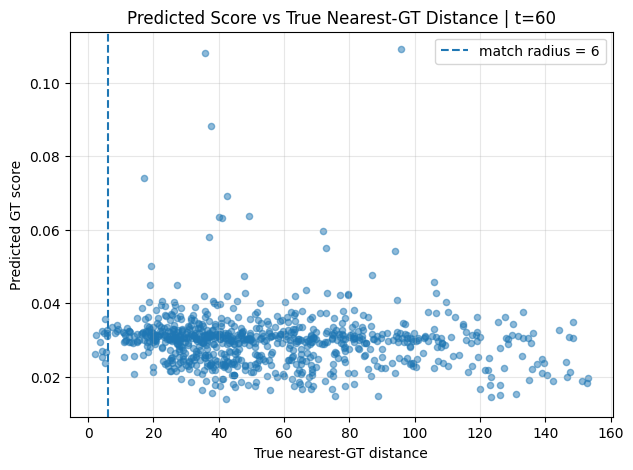

In [18]:
plt.figure(figsize=(7, 5))

plt.scatter(
    ranked_t["nearest_gt_dist"],
    ranked_t["pred_gt_score"],
    alpha=0.5,
    s=20
)

plt.axvline(match_radius, linestyle="--", label=f"match radius = {match_radius}")

plt.title(f"Predicted Score vs True Nearest-GT Distance | t={t_inspect}")
plt.xlabel("True nearest-GT distance")
plt.ylabel("Predicted GT score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Step 11 — Compute Oracle-Good Candidate Retention by Top-K

This checks how many oracle-good candidates are retained by different top-k thresholds.

In [19]:
topk_values = [25, 50, 100, 200, 400, 800]

retention_rows = []

for t, ranked_t in ranked_by_time.items():
    good_t = ranked_t[ranked_t["oracle_good"]].copy()
    total_good = len(good_t)

    for k in topk_values:
        kept_good = (good_t["rank_position"] <= k).sum()

        retention_rows.append({
            "t": t,
            "top_k": k,
            "total_oracle_good_candidates": total_good,
            "kept_oracle_good_candidates": kept_good,
            "fraction_good_retained": kept_good / total_good if total_good > 0 else np.nan
        })

retention_df = pd.DataFrame(retention_rows)
retention_df

,t,top_k,total_oracle_good_candidates,kept_oracle_good_candidates,fraction_good_retained
0,60,25,13,0,0.000000
1,60,50,13,0,0.000000
2,60,100,13,1,0.076923
3,60,200,13,3,0.230769
4,60,400,13,7,0.538462
5,60,800,13,13,1.000000
6,80,25,6,0,0.000000
7,80,50,6,0,0.000000
8,80,100,6,0,0.000000
9,80,200,6,1,0.166667


In [20]:
retention_summary = retention_df.pivot_table(
    index="top_k",
    columns="t",
    values="fraction_good_retained",
    aggfunc="first"
)

retention_summary


t,60,80
top_k,,
25,0.000000,0.000000
50,0.000000,0.000000
100,0.076923,0.000000
200,0.230769,0.166667
400,0.538462,0.666667
800,1.000000,0.833333


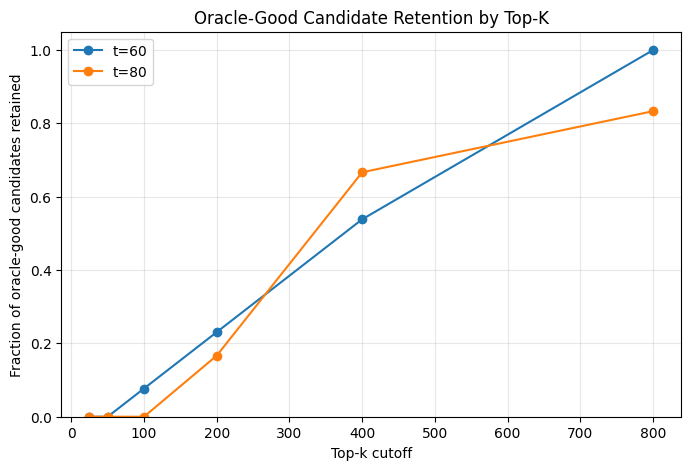

In [21]:
plt.figure(figsize=(8, 5))

for t, group in retention_df.groupby("t"):
    plt.plot(group["top_k"], group["fraction_good_retained"], marker="o", label=f"t={t}")

plt.title("Oracle-Good Candidate Retention by Top-K")
plt.xlabel("Top-k cutoff")
plt.ylabel("Fraction of oracle-good candidates retained")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Step 12 — Interpretation Guide

This chapter tells me whether the ranker is close or far from working.

## If oracle-good candidates are mostly ranked inside top 100
The ranker is close, and I may only need a larger top-k cutoff or better calibration.

## If oracle-good candidates are mostly ranked far below top 100
The ranker is severely misranking candidates.

## If top-ranked bad candidates have high predicted scores
The model is learning the wrong visual signal.

## If predicted score does not decrease as true nearest-GT distance increases
The model is poorly calibrated for held-out frames.

# 📊 Results

The ranking failure is severe rather than mild.

## Held-out timepoint 60
- consolidated candidates: 807
- oracle-good candidates: 13
- best oracle-good rank: 94
- median oracle-good rank: 307
- worst oracle-good rank: 666

## Held-out timepoint 80
- consolidated candidates: 884
- oracle-good candidates: 6
- best oracle-good rank: 104
- median oracle-good rank: 340
- worst oracle-good rank: 819

# 🔍 Analysis

This diagnostic shows that the problem is not candidate coverage. Oracle-good candidates do exist after LoG + NMS.

The problem is that the learned ranker places those good candidates far too low in the ranked list. On both held-out timepoints, even the best oracle-good candidate appears only around rank 100, and the median oracle-good candidate appears around rank 300.

This explains why top-25, top-50, and top-100 filtering failed in Chapter 16. The model is not close to working; it is severely misranking the candidate pool.

# 📝 What I Learned

Today I learned that:

- LoG + NMS still contains GT-near candidates
- the ranking problem is not caused by missing candidates
- the current feature-based ranker does not assign high scores to GT-near candidates
- good candidates often appear only after rank 100 or rank 300
- improving the model will require better features or a different learning setup, not just a different top-k cutoff